#  Tipos de datos en Ciencia de Datos
### Criterio 1 · Comprender y clasificar diferentes tipos de datos

**Fuentes de datos del notebook**
-  Un **archivo Excel** (`datos_tipos_de_datos.xlsx`) que el propio notebook genera: ideal para ver cada tipo de dato "en limpio".
-  Un **dataset público de Kaggle** (`srisyra02/zomato-market-analysis`) descargado con `kagglehub`: datos reales y desordenados.



## Agenda

| # | Sección | Qué aprenderás |
|---|---------|----------------|
| 1 | ¿Por qué importa el tipo de dato? | Qué operaciones son válidas según el tipo |
| 2 | Mapa de tipos de datos | Taxonomía completa |
| 3 | Preparación y fuentes | Excel + Kaggle |
| 4 | Cuantitativos vs cualitativos | Nominal, ordinal, binaria, discreta, continua, intervalo y razón |
| 5 | Datos temporales | Series de tiempo |
| 6 | Datos geoespaciales | Coordenadas y distancias |
| 7 | Datos semiestructurados | JSON |
| 8 | Datos no estructurados | Texto libre (y qué pasa con imagen/audio) |
| 9 | Caso real: Zomato (Kaggle) | Clasificación automática de columnas |
| 10 | Resumen y actividad | Árbol de decisión + ejercicios |

# 1 · ¿Por qué importa el tipo de dato?

El tipo de dato decide **qué cálculos, gráficos y modelos tienen sentido**.

| Tipo | Ejemplo | Cálculo válido | Cálculo sin sentido |
|---|---|---|---|
| Nominal | ciudad | moda, frecuencias | promedio de ciudades |
| Ordinal | satisfacción (baja < media < alta) | mediana, orden | restar "alta − baja" |
| Discreto | número de pedidos | conteos, media | decimales (2.5 pedidos) |
| Continuo | ingreso mensual | media, desviación, correlación | — |
| Intervalo | temperatura en °C | diferencias | razones ("el doble de calor") |
| Razón | ingreso, edad | diferencias y razones | — |

> 💡 Un error típico: guardar un código postal como número y calcular su promedio.

# 2 · Mapa de tipos de datos

```
DATOS
├── Por su ESTRUCTURA
│   ├── Estructurados ........ tablas con filas y columnas (Excel, CSV, SQL)
│   ├── Semiestructurados .... JSON, XML, listas anidadas (tienen etiquetas, no filas fijas)
│   └── No estructurados ..... texto libre, imágenes, audio, video
│
└── Por su NATURALEZA (dentro de los estructurados)
    ├── Cualitativos (categóricos)
    │   ├── Nominal ........... sin orden        → género, ciudad
    │   ├── Ordinal ........... con orden         → nivel educativo, satisfacción
    │   └── Binaria ........... solo 2 valores    → sí/no
    └── Cuantitativos (numéricos)
        ├── Discretos ......... se cuentan        → n.º de pedidos
        ├── Continuos ......... se miden          → ingreso, estatura
        │   ├── Intervalo ..... cero arbitrario   → temperatura °C, fechas
        │   └── Razón ......... cero real         → ingreso, edad
        └── Casos especiales: temporales, geoespaciales (coordenadas)
```

# 3 · Preparación y fuentes de datos


In [5]:
# %pip install -q pandas numpy matplotlib openpyxl kagglehub

import os, re, glob, json, ast, math, warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.width", 200)
plt.rcParams.update({
    "figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": .3,
    "axes.spines.top": False, "axes.spines.right": False, "axes.titleweight": "bold",
})
print("pandas", pd.__version__, "· numpy", np.__version__)

pandas 3.0.6 · numpy 2.4.6


### 3.1 Fuente A · Archivo Excel generado

El notebook crea (si no existe) un Excel con **5 hojas**, cada una pensada para mostrar un tipo de dato:

| Hoja | Contenido | Tipos que ilustra |
|---|---|---|
| `clientes` | 300 clientes de una app de comida | nominal, ordinal, binaria, discreta, continua, ID, fecha |
| `ventas_diarias` | 180 días de ventas | series de tiempo, intervalo vs razón |
| `sucursales` | 8 locales en Ecuador | geoespacial |
| `productos_json` | fichas de producto en JSON | semiestructurado |
| `resenas` | 120 opiniones de clientes | no estructurado (texto) |

In [6]:
ARCHIVO_EXCEL = "../BDD/datos_tipos_de_datos.xlsx"


def generar_excel(ruta):
    rng = np.random.default_rng(42)
    n = 300
    ciudades = ["Quito", "Guayaquil", "Ambato", "Cuenca", "Loja", "Riobamba", "Latacunga", "Píllaro"]

    # --- Hoja 1: clientes (datos estructurados de varias escalas)
    clientes = pd.DataFrame({
        "id_cliente": np.arange(1001, 1001 + n),
        "genero": rng.choice(["Femenino", "Masculino", "Otro"], n, p=[.48, .48, .04]),
        "ciudad": rng.choice(ciudades, n),
        "nivel_educacion": rng.choice(["Básico", "Bachillerato", "Tercer nivel", "Posgrado"], n, p=[.10, .35, .40, .15]),
        "satisfaccion": rng.choice(["Muy baja", "Baja", "Media", "Alta", "Muy alta"], n, p=[.05, .10, .25, .40, .20]),
        "edad": rng.integers(18, 70, n),
        "num_pedidos": rng.poisson(6, n),
        "ingreso_mensual_usd": np.round(rng.lognormal(6.7, 0.4, n), 2),
        "estatura_cm": np.round(rng.normal(165, 9, n), 1),
        "es_suscriptor": rng.choice(["Sí", "No"], n, p=[.35, .65]),
        "fecha_registro": pd.to_datetime("2024-01-01") + pd.to_timedelta(rng.integers(0, 600, n), unit="D"),
    })

    # --- Hoja 2: ventas diarias (serie de tiempo)
    t = np.arange(180)
    ventas = pd.DataFrame({
        "fecha": pd.date_range("2025-01-01", periods=180, freq="D"),
        "ventas_usd": np.round(800 + 2.5 * t + 120 * np.sin(2 * np.pi * t / 7) + rng.normal(0, 40, 180), 2),
        "temperatura_c": np.round(14 + 3 * np.sin(2 * np.pi * t / 90) + rng.normal(0, 1.2, 180), 1),
        "visitas_web": rng.poisson(300 + t),
    })

    # --- Hoja 3: sucursales (geoespacial)
    sucursales = pd.DataFrame({
        "id_sucursal": np.arange(1, 9),
        "nombre": [f"Sucursal {c}" for c in ciudades],
        "latitud": [-0.1807, -2.1710, -1.2417, -2.9001, -3.9931, -1.6636, -0.9346, -1.1700],
        "longitud": [-78.4678, -79.9224, -78.6197, -79.0059, -79.2042, -78.6546, -78.6157, -78.5400],
        "tipo_local": ["Restaurante", "Restaurante", "Cafetería", "Restaurante", "Dark kitchen", "Cafetería", "Dark kitchen", "Cafetería"],
    })

    # --- Hoja 4: productos en JSON (semiestructurado)
    categorias = ["Bebidas", "Postres", "Platos fuertes", "Entradas"]
    etiquetas = ["vegano", "picante", "sin gluten", "temporada", "promoción", "nuevo"]
    filas = []
    for i in range(1, 41):
        ficha = {
            "nombre": f"Producto {i}",
            "categoria": str(rng.choice(categorias)),
            "precio": float(np.round(rng.uniform(1.5, 18), 2)),
            "etiquetas": [str(e) for e in rng.choice(etiquetas, int(rng.integers(0, 4)), replace=False)],
            "dimensiones": {"alto_cm": int(rng.integers(3, 20)), "ancho_cm": int(rng.integers(5, 30))},
            "disponible": bool(rng.random() > .2),
        }
        filas.append({"id_producto": 5000 + i, "ficha_json": json.dumps(ficha, ensure_ascii=False)})
    productos = pd.DataFrame(filas)

    # --- Hoja 5: reseñas (texto libre, no estructurado)
    pos = ["La comida llegó caliente y muy rápido", "Excelente atención del personal",
           "Los precios son justos y la porción generosa", "El sabor es increíble, volveré pronto",
           "Ambiente agradable y limpio"]
    neg = ["El pedido llegó tarde y frío", "Mala atención, nadie me ayudó",
           "Muy caro para la porción que sirven", "La comida estaba sosa", "El lugar estaba sucio y ruidoso"]
    extra = ["Pedí por la app el fin de semana", "Fui con mi familia", "Era mi segunda vez", "Lo pedí para la oficina"]
    textos, punt = [], []
    for _ in range(120):
        k = int(rng.integers(2, 4))
        eleg = [("p", str(rng.choice(pos))) if rng.random() < .55 else ("n", str(rng.choice(neg))) for _ in range(k)]
        share = sum(1 for e in eleg if e[0] == "p") / k
        textos.append(". ".join(e[1] for e in eleg) + ". " + str(rng.choice(extra)) + ".")
        punt.append(int(np.clip(round(1 + 4 * share + rng.normal(0, .5)), 1, 5)))
    resenas = pd.DataFrame({
        "id_resena": np.arange(1, 121),
        "texto": textos,
        "puntuacion": punt,
        "fecha": pd.to_datetime("2025-01-01") + pd.to_timedelta(rng.integers(0, 180, 120), unit="D"),
    })

    with pd.ExcelWriter(ruta, engine="openpyxl") as w:
        clientes.to_excel(w, sheet_name="clientes", index=False)
        ventas.to_excel(w, sheet_name="ventas_diarias", index=False)
        sucursales.to_excel(w, sheet_name="sucursales", index=False)
        productos.to_excel(w, sheet_name="productos_json", index=False)
        resenas.to_excel(w, sheet_name="resenas", index=False)


if not os.path.exists(ARCHIVO_EXCEL):
    generar_excel(ARCHIVO_EXCEL)
    print("✅ Excel generado:", ARCHIVO_EXCEL)
else:
    print("📗 Usando Excel existente:", ARCHIVO_EXCEL)

hojas = pd.read_excel(ARCHIVO_EXCEL, sheet_name=None)
clientes, ventas, sucursales, productos, resenas = (
    hojas[k] for k in ["clientes", "ventas_diarias", "sucursales", "productos_json", "resenas"])
print({k: v.shape for k, v in hojas.items()})

📗 Usando Excel existente: ../BDD/datos_tipos_de_datos.xlsx
{'clientes': (300, 11), 'ventas_diarias': (180, 4), 'sucursales': (8, 5), 'productos_json': (40, 2), 'resenas': (120, 4)}


### 3.2 Herramienta del notebook · el clasificador de columnas

Para no clasificar "a ojo", definimos una función `perfil_tabla()` que **propone** el tipo de cada columna usando reglas simples (tipo de pandas, número de valores únicos, patrones del texto, nombre de la columna).

> ⚠️ Es una **heurística**: sirve para acelerar el análisis, pero la decisión final siempre es del analista (por ejemplo, una puntuación 1–5 guardada como número sigue siendo *ordinal*).

In [8]:
ORDINALES = [
    ["muy baja", "baja", "media", "alta", "muy alta"],
    ["básico", "bachillerato", "tercer nivel", "posgrado"],
    ["bajo", "medio", "alto"], ["low", "medium", "high"],
    ["poor", "average", "good", "very good", "excellent"],
    ["not rated", "poor", "average", "good", "very good", "excellent"],
    ["nunca", "a veces", "casi siempre", "siempre"],
    ["strongly disagree", "disagree", "neutral", "agree", "strongly agree"],
]
RE_COORD = r"(^|_)(lat|lon|lng|latitud|longitud|latitude|longitude)"
RE_GEO = r"city|location|address|area|country|zone|ciudad|direcc|barrio|region|state"
RE_ID = r"(^|_)(id|code|codigo|cod)(_|$)"
RE_ESCALA = r"rating|rate|puntu|score|satisf|nivel|grado"


def _fila(naturaleza, escala, estructura):
    return {"naturaleza": naturaleza, "escala": escala, "estructura": estructura}


def _a_numero(s):
    t = (s.astype(str).str.strip()
         .str.replace(r"\s*/\s*\d+(\.\d+)?$", "", regex=True)
         .str.replace(",", "", regex=False)
         .str.replace(r"^[\$€£]", "", regex=True))
    return pd.to_numeric(t, errors="coerce")


def _es_json(muestra):
    m = muestra.str.strip().head(100)
    ini = m.str.startswith(("{", "[")).mean()
    if ini < .8:
        return False
    ok = 0
    for v in m[m.str.startswith(("{", "["))]:
        try:
            json.loads(v); ok += 1
        except Exception:
            try:
                ast.literal_eval(v); ok += 1
            except Exception:
                pass
    return ok / max(1, int(m.str.startswith(("{", "[")).sum())) >= .7


def _es_fecha(muestra):
    m = muestra.head(300)
    patron = m.str.contains(r"\d{1,4}[-/.]\d{1,2}[-/.]\d{1,4}", regex=True).mean()
    if patron < .8:
        return False
    return pd.to_datetime(m, errors="coerce").notna().mean() >= .8


def _vocab_ordinal(valores):
    vals = {str(v).strip().lower() for v in valores}
    for voc in ORDINALES:
        if len(vals & set(voc)) >= 2 and len(vals & set(voc)) / len(vals) >= .7:
            return voc
    return None


def _clasif_numerica(vals, nm, desde_texto=False):
    nota = " · guardada como texto" if desde_texto else ""
    es_ent = bool(np.all(np.isclose(vals, np.round(vals))))
    if re.search(RE_COORD, nm):
        return _fila("Cuantitativo", "Coordenada geográfica (continua)" + nota, "Estructurado")
    if es_ent and vals.nunique() == len(vals) and re.search(RE_ID, nm):
        return _fila("Cualitativo", "Identificador (nominal)" + nota, "Estructurado")
    if es_ent and vals.nunique() <= 10 and re.search(RE_ESCALA, nm):
        return _fila("Cualitativo", "Ordinal (codificada con números)" + nota, "Estructurado")
    if es_ent:
        return _fila("Cuantitativo", "Discreta" + nota, "Estructurado")
    return _fila("Cuantitativo", "Continua" + nota, "Estructurado")


def clasificar_columna(s, nombre=None):
    nm = str(nombre if nombre is not None else s.name).lower()
    nn = s.dropna()
    if len(nn) == 0:
        return _fila("—", "Vacía", "—")
    if pd.api.types.is_datetime64_any_dtype(s):
        return _fila("Cuantitativo", "Intervalo (fecha/hora)", "Estructurado")
    if pd.api.types.is_bool_dtype(s) or nn.nunique() == 2:
        return _fila("Cualitativo", "Binaria (dicotómica)", "Estructurado")
    if pd.api.types.is_numeric_dtype(s):
        return _clasif_numerica(nn, nm)

    # a partir de aquí: columnas de texto
    txt = nn.astype(str)
    muestra = txt.head(2000)
    if _es_json(muestra):
        return _fila("Compuesto", "No aplica (estructura anidada)", "Semiestructurado")
    num = _a_numero(muestra)
    if num.notna().mean() >= .85:
        return _clasif_numerica(_a_numero(txt).dropna(), nm, desde_texto=True)
    if _es_fecha(muestra):
        return _fila("Cuantitativo", "Intervalo (fecha/hora) · guardada como texto", "Estructurado")
    voc = _vocab_ordinal(txt.unique())
    if voc:
        return _fila("Cualitativo", "Ordinal", "Estructurado")
    if muestra.str.len().mean() > 40 or muestra.str.split().str.len().mean() >= 6:
        return _fila("Cualitativo", "No aplica (texto libre)", "No estructurado")
    geo = " (geográfica)" if re.search(RE_GEO, nm) else ""
    if nn.nunique() <= max(30, .05 * len(nn)) or nn.nunique() / len(nn) < .5:
        return _fila("Cualitativo", "Nominal" + geo, "Estructurado")
    return _fila("Cualitativo", "Nominal (alta cardinalidad)" + geo, "Estructurado")


def perfil_tabla(df, max_filas=20000):
    d = df.sample(max_filas, random_state=0) if len(df) > max_filas else df
    d = d.apply(lambda c: c.map(lambda x: str(x) if isinstance(x, (list, dict)) else x))
    filas = []
    for c in d.columns:
        info = clasificar_columna(d[c], c)
        try:
            unicos = int(d[c].nunique())
        except Exception:
            unicos = None
        ej = d[c].dropna()
        ej = str(ej.iloc[0])[:38] if len(ej) else ""
        filas.append({"columna": c, "tipo_pandas": str(df[c].dtype), **info,
                      "nulos_%": round(df[c].isna().mean() * 100, 1), "únicos": unicos, "ejemplo": ej})
    return pd.DataFrame(filas)


print("✅ Clasificador listo")

✅ Clasificador listo


# 4 · Datos estructurados: cualitativos vs cuantitativos

Empezamos con la hoja **`clientes`**. Mira primero los datos crudos y luego lo que propone el clasificador.

In [9]:
display(clientes.head(8))
perfil_clientes = perfil_tabla(clientes)
display(perfil_clientes)

,id_cliente,genero,ciudad,nivel_educacion,satisfaccion,edad,num_pedidos,ingreso_mensual_usd,estatura_cm,es_suscriptor,fecha_registro
0,1001,Masculino,Loja,Básico,Media,65,5,979.00,162.3,No,2024-05-18
1,1002,Femenino,Latacunga,Posgrado,Media,52,8,479.73,169.0,No,2024-04-24
2,1003,Masculino,Riobamba,Tercer nivel,Media,26,5,1317.25,164.5,No,2025-02-12
3,1004,Masculino,Guayaquil,Bachillerato,Alta,24,8,1985.52,165.1,No,2024-02-06
4,1005,Femenino,Latacunga,Básico,Alta,63,5,1212.86,170.9,No,2024-11-18
5,1006,Otro,Loja,Bachillerato,Media,32,3,1437.69,158.5,No,2024-09-26
6,1007,Masculino,Ambato,Posgrado,Media,57,4,840.63,165.4,No,2025-03-22
7,1008,Masculino,Loja,Tercer nivel,Muy alta,25,6,417.97,162.2,No,2024-05-01


,columna,tipo_pandas,naturaleza,escala,estructura,nulos_%,únicos,ejemplo
0,id_cliente,int64,Cualitativo,Identificador (nominal),Estructurado,0.0,300,1001
1,genero,str,Cualitativo,Nominal,Estructurado,0.0,3,Masculino
2,ciudad,str,Cualitativo,Nominal (geográfica),Estructurado,0.0,8,Loja
3,nivel_educacion,str,Cualitativo,Ordinal,Estructurado,0.0,4,Básico
4,satisfaccion,str,Cualitativo,Ordinal,Estructurado,0.0,5,Media
5,edad,int64,Cuantitativo,Discreta,Estructurado,0.0,52,65
6,num_pedidos,int64,Cuantitativo,Discreta,Estructurado,0.0,15,5
7,ingreso_mensual_usd,float64,Cuantitativo,Continua,Estructurado,0.0,300,979.0
8,estatura_cm,float64,Cuantitativo,Continua,Estructurado,0.0,198,162.3
9,es_suscriptor,str,Cualitativo,Binaria (dicotómica),Estructurado,0.0,2,No


**Lectura rápida del perfil**
- `id_cliente` → identificador: es un número, pero **no se promedia**.
- `genero`, `ciudad` → nominales. `nivel_educacion`, `satisfaccion` → ordinales.
- `es_suscriptor` → binaria. `edad`, `num_pedidos` → discretas.
- `ingreso_mensual_usd`, `estatura_cm` → continuas. `fecha_registro` → fecha (intervalo).

## 4.1 Cualitativo · Nominal
Categorías **sin orden natural**. Lo único que podemos hacer es contar y obtener la **moda**.

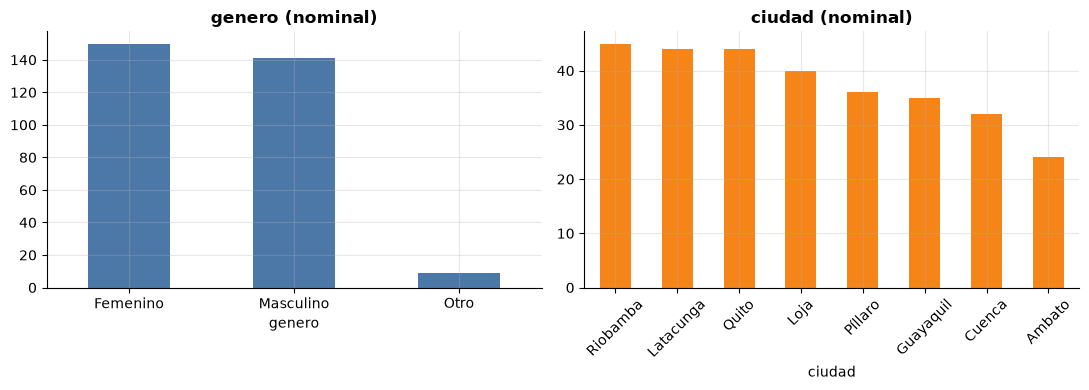

Moda de ciudad: Riobamba
 Promedio de ciudades: no existe.  Proporciones:
ciudad
Riobamba     0.150
Latacunga    0.147
Quito        0.147
Name: proportion, dtype: float64


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
clientes["genero"].value_counts().plot.bar(ax=ax[0], color="#4C78A8", title="genero (nominal)", rot=0)
clientes["ciudad"].value_counts().plot.bar(ax=ax[1], color="#F58518", title="ciudad (nominal)", rot=45)
plt.tight_layout(); plt.show()
print("Moda de ciudad:", clientes["ciudad"].mode()[0])
print(" Promedio de ciudades: no existe.  Proporciones:")
print(clientes["ciudad"].value_counts(normalize=True).round(3).head(3))

## 4.2 Cualitativo · Ordinal
Categorías **con orden**, pero la distancia entre ellas no es medible (¿cuánto más es "Alta" que "Media"?).
En pandas se representa con `Categorical(..., ordered=True)`.

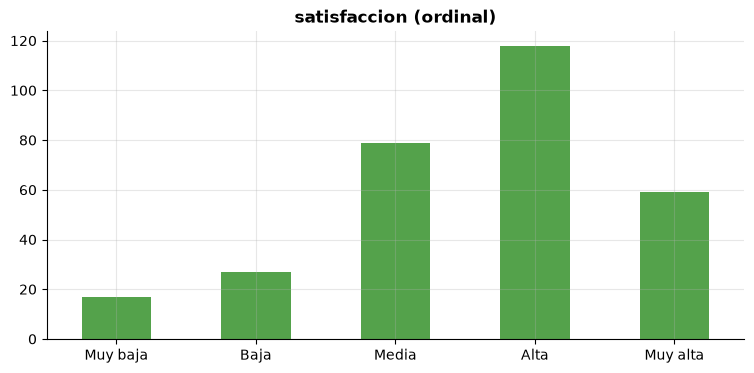

Mínimo: Muy baja | Máximo: Muy alta
Mediana (categoría central): Alta
¿Hay clientes por encima de 'Media'? 177 de 300


In [12]:
orden = ["Muy baja", "Baja", "Media", "Alta", "Muy alta"]
sat = pd.Series(pd.Categorical(clientes["satisfaccion"], categories=orden, ordered=True))

sat.value_counts().sort_index().plot.bar(color="#54A24B", title="satisfaccion (ordinal)", rot=0)
plt.show()

ordenada = sat.sort_values().reset_index(drop=True)
print("Mínimo:", sat.min(), "| Máximo:", sat.max())
print("Mediana (categoría central):", ordenada[len(ordenada) // 2])
print("¿Hay clientes por encima de 'Media'?", (sat > "Media").sum(), "de", len(sat))

## 4.3 Cualitativo · Binaria
Solo **dos valores posibles**. Si la codificamos como 0/1, su **media es una proporción**.

In [13]:
bin01 = clientes["es_suscriptor"].map({"Sí": 1, "No": 0})
print(clientes["es_suscriptor"].value_counts())
print(f"Media de la variable 0/1 = proporción de suscriptores = {bin01.mean():.3f}")

es_suscriptor
No    194
Sí    106
Name: count, dtype: int64
Media de la variable 0/1 = proporción de suscriptores = 0.353


## 4.4 Cuantitativo · Discreto
Valores que **se cuentan** (enteros). No existen "2.5 pedidos".

¿Todos enteros? True


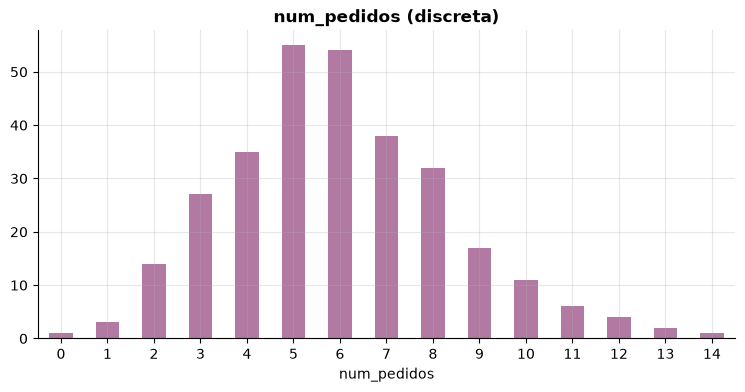

Media: 5.97 | Mediana: 6.0


In [14]:
print("¿Todos enteros?", bool((clientes["num_pedidos"] % 1 == 0).all()))
clientes["num_pedidos"].value_counts().sort_index().plot.bar(color="#B279A2", title="num_pedidos (discreta)", rot=0)
plt.show()
print("Media:", round(clientes["num_pedidos"].mean(), 2), "| Mediana:", clientes["num_pedidos"].median())

## 4.5 Cuantitativo · Continuo
Valores que **se miden** y pueden tomar cualquier valor dentro de un rango (con decimales).
Observa cómo el ingreso tiene cola a la derecha (asimetría), mientras la estatura es casi simétrica.

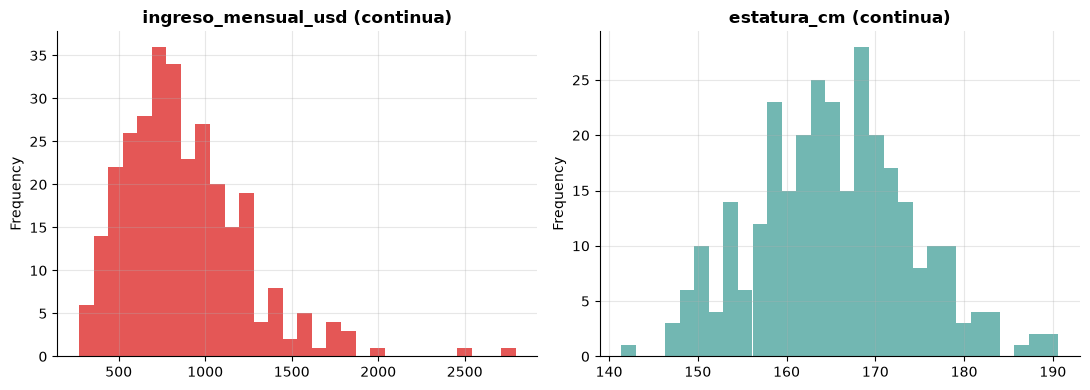

Asimetría ingreso : 1.32
Asimetría estatura: 0.13


In [15]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
clientes["ingreso_mensual_usd"].plot.hist(bins=30, ax=ax[0], color="#E45756", title="ingreso_mensual_usd (continua)")
clientes["estatura_cm"].plot.hist(bins=30, ax=ax[1], color="#72B7B2", title="estatura_cm (continua)")
plt.tight_layout(); plt.show()
print("Asimetría ingreso :", round(clientes["ingreso_mensual_usd"].skew(), 2))
print("Asimetría estatura:", round(clientes["estatura_cm"].skew(), 2))

## 4.6 Escala de **intervalo** vs escala de **razón**

| | Intervalo | Razón |
|---|---|---|
| ¿Cero real (ausencia)? | No (cero arbitrario) | Sí |
| Diferencias con sentido | ✅ | ✅ |
| Razones ("el doble") con sentido | ❌ | ✅ |
| Ejemplo | Temperatura en °C, fechas | Ingreso, edad, ventas |

In [16]:
temp = ventas["temperatura_c"]
print(f"Temperatura media: {temp.mean():.1f} °C")
print("Razón 20 °C / 10 °C =", 20 / 10, "→ ❌ pero 20 °C NO es 'el doble de calor'")
print("En Kelvin (cero real):", round((20 + 273.15) / (10 + 273.15), 3), "→ ✅ la razón real es casi 1")
print()
print("Ingreso USD 2000 / USD 1000 =", 2000 / 1000, "→ ✅ sí es el doble de dinero (cero real)")

Temperatura media: 14.1 °C
Razón 20 °C / 10 °C = 2.0 → ❌ pero 20 °C NO es 'el doble de calor'
En Kelvin (cero real): 1.035 → ✅ la razón real es casi 1

Ingreso USD 2000 / USD 1000 = 2.0 → ✅ sí es el doble de dinero (cero real)


## 4.7 Identificadores
Un número que **solo identifica**. Operaciones aritméticas sobre él no tienen significado.

In [17]:
print("id_cliente → únicos:", clientes["id_cliente"].nunique(), "de", len(clientes), "filas")
print("❌ Promedio del ID:", round(clientes["id_cliente"].mean(), 1), "(no significa nada)")

id_cliente → únicos: 300 de 300 filas
❌ Promedio del ID: 1150.5 (no significa nada)


# 5 · Datos temporales (series de tiempo)

Una **serie de tiempo** es una variable observada a intervalos regulares. El **orden importa**: no se puede mezclar las filas sin perder información.
Componentes típicos: **tendencia**, **estacionalidad** y **ruido**.

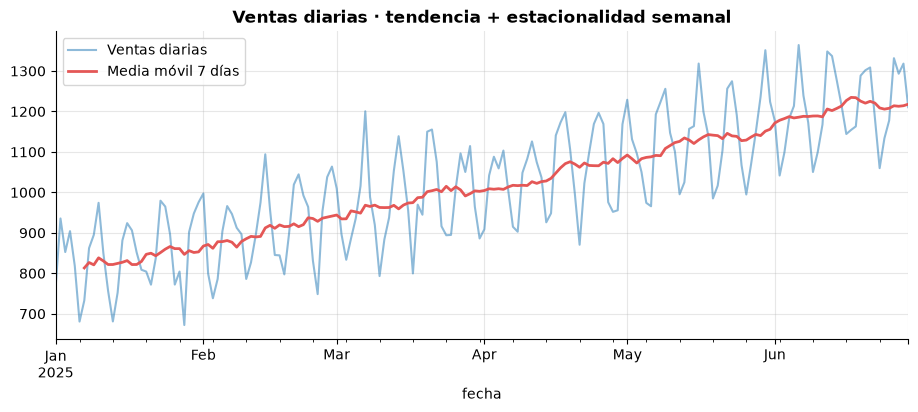

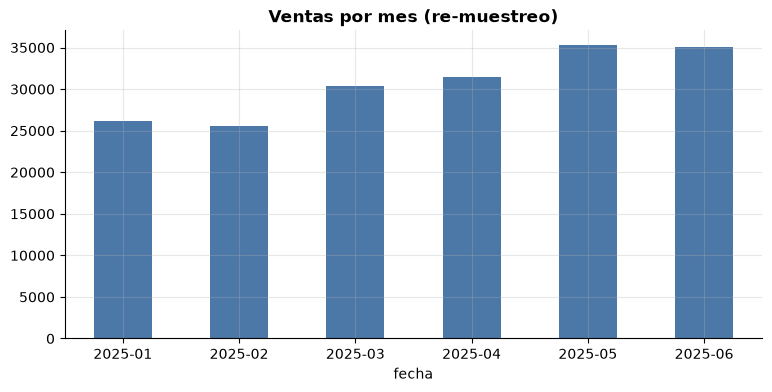

,fecha,dia_semana,mes,es_fin_de_semana
0,2025-01-01,Wednesday,1,False
1,2025-01-02,Thursday,1,False
2,2025-01-03,Friday,1,False
3,2025-01-04,Saturday,1,True
4,2025-01-05,Sunday,1,True


In [18]:
v = ventas.set_index("fecha")
fig, ax = plt.subplots(figsize=(11, 4))
v["ventas_usd"].plot(ax=ax, alpha=.5, label="Ventas diarias")
v["ventas_usd"].rolling(7).mean().plot(ax=ax, color="#E45756", lw=2, label="Media móvil 7 días")
ax.set_title("Ventas diarias · tendencia + estacionalidad semanal"); ax.legend(); plt.show()

mensual = v["ventas_usd"].resample("MS").sum()
mensual.index = mensual.index.strftime("%Y-%m")
mensual.plot.bar(color="#4C78A8", title="Ventas por mes (re-muestreo)", rot=0); plt.show()

# componentes de una fecha → nuevas variables
partes = pd.DataFrame({"fecha": v.index[:5], "dia_semana": v.index[:5].day_name(),
                       "mes": v.index[:5].month, "es_fin_de_semana": v.index[:5].dayofweek >= 5})
display(partes)

# 6 · Datos geoespaciales

Se describen con **coordenadas** (latitud y longitud, ambas continuas). Permiten calcular **distancias**, cercanías y mapas.

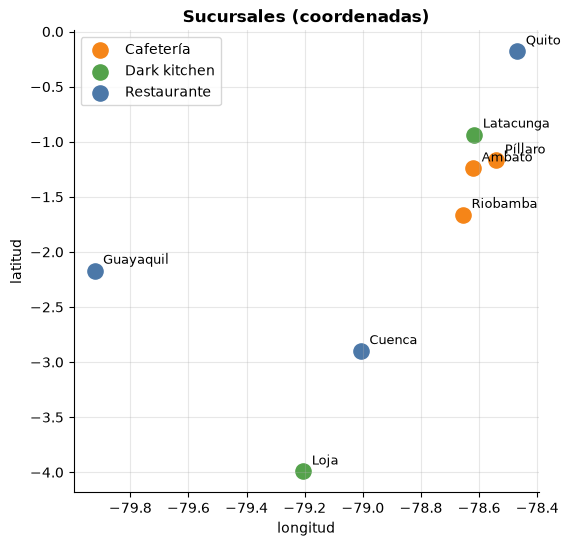

Distancia Quito–Ambato (línea recta): 119 km


In [19]:
def haversine_km(lat1, lon1, lat2, lon2):
    r = 6371.0
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dphi, dl = p2 - p1, math.radians(lon2 - lon1)
    a = math.sin(dphi / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(dl / 2) ** 2
    return 2 * r * math.asin(math.sqrt(a))


fig, ax = plt.subplots(figsize=(6, 6))
colores = {"Restaurante": "#4C78A8", "Cafetería": "#F58518", "Dark kitchen": "#54A24B"}
for tipo, g in sucursales.groupby("tipo_local"):
    ax.scatter(g["longitud"], g["latitud"], s=120, label=tipo, color=colores[tipo])
for _, f in sucursales.iterrows():
    ax.annotate(f["nombre"].replace("Sucursal ", ""), (f["longitud"], f["latitud"]),
                textcoords="offset points", xytext=(6, 5), fontsize=9)
ax.set_xlabel("longitud"); ax.set_ylabel("latitud"); ax.set_title("Sucursales (coordenadas)"); ax.legend()
plt.show()

q = sucursales.set_index("nombre").loc["Sucursal Quito"]
a = sucursales.set_index("nombre").loc["Sucursal Ambato"]
print(f"Distancia Quito–Ambato (línea recta): {haversine_km(q.latitud, q.longitud, a.latitud, a.longitud):.0f} km")

# 7 · Datos semiestructurados (JSON)

Tienen **etiquetas** (claves) pero **no una forma fija de tabla**: pueden traer listas, campos opcionales y objetos anidados.
Son el formato típico de las **APIs web**. Para analizarlos hay que **aplanarlos** (`json_normalize`).

In [20]:
display(productos.head(3))
primera = json.loads(productos.loc[0, "ficha_json"])
print(json.dumps(primera, indent=2, ensure_ascii=False))

,id_producto,ficha_json
0,5001,"{""nombre"": ""Producto 1"", ""categoria"": ""Platos fuertes"", ..."
1,5002,"{""nombre"": ""Producto 2"", ""categoria"": ""Platos fuertes"", ..."
2,5003,"{""nombre"": ""Producto 3"", ""categoria"": ""Entradas"", ""preci..."


{
  "nombre": "Producto 1",
  "categoria": "Platos fuertes",
  "precio": 8.75,
  "etiquetas": [],
  "dimensiones": {
    "alto_cm": 5,
    "ancho_cm": 10
  },
  "disponible": true
}


In [21]:
fichas = productos["ficha_json"].apply(json.loads)
planas = pd.json_normalize(fichas.tolist())
planas.insert(0, "id_producto", productos["id_producto"])
display(planas.head())

print("Columnas nuevas tras aplanar:", [c for c in planas.columns if "." in c])
planas["n_etiquetas"] = planas["etiquetas"].apply(len)   # la lista se convierte en variable discreta
print("\nPrecio medio por categoría:")
print(planas.groupby("categoria")["precio"].mean().round(2))

,id_producto,nombre,categoria,precio,etiquetas,disponible,dimensiones.alto_cm,dimensiones.ancho_cm
0,5001,Producto 1,Platos fuertes,8.75,[],True,5,10
1,5002,Producto 2,Platos fuertes,6.44,"[vegano, nuevo, temporada]",True,11,13
2,5003,Producto 3,Entradas,2.41,[],True,3,26
3,5004,Producto 4,Bebidas,11.75,[],True,12,19
4,5005,Producto 5,Postres,6.96,[nuevo],True,4,27


Columnas nuevas tras aplanar: ['dimensiones.alto_cm', 'dimensiones.ancho_cm']

Precio medio por categoría:
categoria
Bebidas           9.75
Entradas          6.94
Platos fuertes    5.75
Postres           7.96
Name: precio, dtype: float64


# 8 · Datos no estructurados (texto libre)

No tienen modelo de columnas: **texto**, **imágenes**, **audio**, **video**. Para analizarlos primero hay que **extraer características** que sí sean estructuradas.

| Dato | Cómo se vuelve estructurado |
|---|---|
| Texto | conteo de palabras, frecuencia de términos, sentimiento |
| Imagen | matriz de píxeles, características de un modelo de visión |
| Audio | espectrograma, transcripción |

,id_resena,texto,puntuacion,fecha
0,1,Ambiente agradable y limpio. Los precios son justos y la...,4,2025-05-31
1,2,Excelente atención del personal. Excelente atención del ...,5,2025-05-23
2,3,La comida estaba sosa. Ambiente agradable y limpio. Exce...,4,2025-01-28
3,4,Excelente atención del personal. El pedido llegó tarde y...,3,2025-05-11


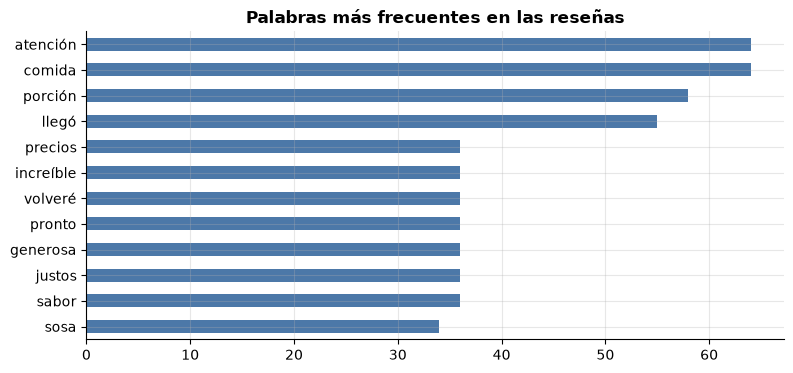

In [22]:
display(resenas.head(4))

palabras = resenas["texto"].str.lower().str.findall(r"[a-záéíóúñü]+")
stop = {"para", "muy", "con", "que", "los", "las", "una", "por", "del", "mis", "mi", "pedí", "fui", "era",
        "segunda", "vez", "app", "fin", "semana", "familia", "oficina", "pedido", "lugar", "estaba", "como", "nadie"}
conteo = Counter(w for lista in palabras for w in lista if w not in stop and len(w) > 3)
pd.Series(dict(conteo.most_common(12))).sort_values().plot.barh(color="#4C78A8", title="Palabras más frecuentes en las reseñas")
plt.show()

**De texto a variables estructuradas** (*feature engineering*): creamos columnas numéricas a partir del texto y comprobamos si se relacionan con la puntuación.

,texto,n_palabras,n_pos,n_neg,sentimiento,puntuacion
0,Ambiente agradable y limpio. Los precios son justos y la...,17,4,0,4,4
1,Excelente atención del personal. Excelente atención del ...,13,2,0,2,5
2,La comida estaba sosa. Ambiente agradable y limpio. Exce...,16,3,1,2,4
3,Excelente atención del personal. El pedido llegó tarde y...,20,1,4,-3,3
4,El lugar estaba sucio y ruidoso. La comida estaba sosa. ...,14,0,3,-3,1


Correlación sentimiento (extraído del texto) vs puntuación: 0.82


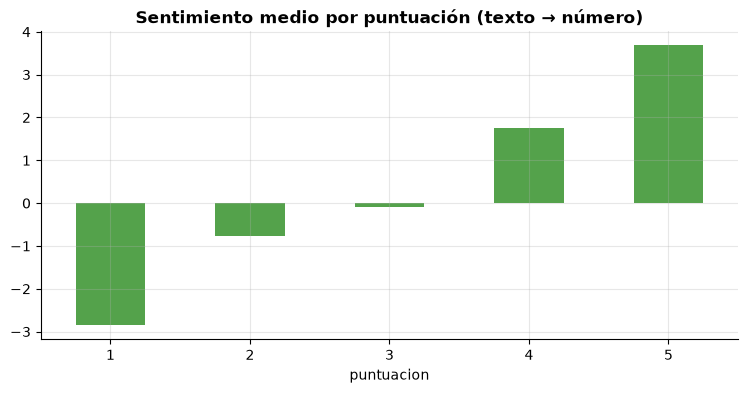

In [23]:
POS = {"rápido", "excelente", "justos", "generosa", "increíble", "volveré", "agradable", "limpio"}
NEG = {"tarde", "frío", "mala", "caro", "sosa", "sucio", "ruidoso"}

resenas["n_palabras"] = palabras.apply(len)
resenas["n_pos"] = palabras.apply(lambda l: sum(w in POS for w in l))
resenas["n_neg"] = palabras.apply(lambda l: sum(w in NEG for w in l))
resenas["sentimiento"] = resenas["n_pos"] - resenas["n_neg"]

display(resenas[["texto", "n_palabras", "n_pos", "n_neg", "sentimiento", "puntuacion"]].head(5))
print("Correlación sentimiento (extraído del texto) vs puntuación:",
      round(resenas["sentimiento"].corr(resenas["puntuacion"]), 2))
resenas.groupby("puntuacion")["sentimiento"].mean().plot.bar(color="#54A24B", rot=0,
        title="Sentimiento medio por puntuación (texto → número)")
plt.show()

# 9 · Caso real: Zomato (Kaggle)

Dataset público: **`srisyra02/zomato-market-analysis`**, descargado con `kagglehub`.

Aquí no sabemos de antemano qué columnas tiene: usaremos el clasificador para **descubrir y clasificar** cada una.



In [24]:
RUTA_ZOMATO = None
try:
    import kagglehub
    RUTA_ZOMATO = kagglehub.dataset_download("srisyra02/zomato-market-analysis")
    print("✅ Descargado con kagglehub en:", RUTA_ZOMATO)
except Exception as e:
    print("⚠️ No se pudo descargar con kagglehub:", type(e).__name__, "-", str(e)[:150])
    local = os.environ.get("ZOMATO_LOCAL") or ("zomato_local" if os.path.isdir("zomato_local") else None)
    if local:
        RUTA_ZOMATO = local
        print("📁 Usando copia local:", RUTA_ZOMATO)
    else:
        print("""
Cómo continuar:
  1) pip install kagglehub  (y, si pide credenciales, crea kaggle.json en Kaggle > Settings > API
     o define KAGGLE_USERNAME y KAGGLE_KEY), o bien
  2) descarga el ZIP desde la página del dataset en Kaggle, descomprímelo en una carpeta
     llamada 'zomato_local' junto a este notebook y vuelve a ejecutar esta celda.""")

100%|██████████| 434k/434k [00:00<00:00, 874kB/s]

Extracting files...
✅ Descargado con kagglehub en: C:\Users\alexm\.cache\kagglehub\datasets\srisyra02\zomato-market-analysis\versions\1


In [25]:
def leer_archivo(ruta):
    ext = ruta.lower().rsplit(".", 1)[-1]
    if ext == "csv":
        for enc in ("utf-8", "latin-1"):
            try:
                return pd.read_csv(ruta, encoding=enc, low_memory=False)
            except UnicodeDecodeError:
                continue
    if ext in ("xlsx", "xls"):
        return pd.read_excel(ruta)
    if ext == "json":
        try:
            return pd.read_json(ruta)
        except ValueError:
            return pd.read_json(ruta, lines=True)
    raise ValueError(f"Formato no soportado: {ruta}")


ARCHIVO_ZOMATO = None   # opcional: escribe aquí el nombre de un archivo concreto, p. ej. "zomato.csv"
df_z = None

if RUTA_ZOMATO:
    archivos = [f for f in glob.glob(os.path.join(RUTA_ZOMATO, "**", "*"), recursive=True)
                if f.lower().endswith((".csv", ".xlsx", ".xls", ".json"))]
    archivos.sort(key=os.path.getsize, reverse=True)
    print("Archivos encontrados:")
    for f in archivos:
        print(f"  · {os.path.relpath(f, RUTA_ZOMATO)}  ({os.path.getsize(f)/1e6:.2f} MB)")
    if archivos:
        elegido = next((f for f in archivos if ARCHIVO_ZOMATO and os.path.basename(f) == ARCHIVO_ZOMATO), archivos[0])
        df_z = leer_archivo(elegido)
        print(f"\n➡️ Analizando: {os.path.basename(elegido)} · {df_z.shape[0]:,} filas × {df_z.shape[1]} columnas")
        display(df_z.head(5))
    else:
        print("No se encontraron archivos csv/xlsx/json en la ruta.")
else:
    print("Sin dataset de Zomato disponible: se omiten las secciones 9.x (el resto del notebook sigue válido).")

Archivos encontrados:
  · Zomato Restaurant Dataset.csv  (2.26 MB)

➡️ Analizando: Zomato Restaurant Dataset.csv · 9,551 filas × 21 columnas


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenue, Poblaci...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Makati City",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi Village, ...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Makati City",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Mandaluyong ...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, Ortigas, Ma...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandaluyong City",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas, Mandaluy...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandaluyong City",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## 9.1 Perfil automático de las columnas

In [26]:
if df_z is not None:
    perfil_z = perfil_tabla(df_z)
    display(perfil_z)
else:
    print("— sin datos de Zomato —")

,columna,tipo_pandas,naturaleza,escala,estructura,nulos_%,únicos,ejemplo
0,Restaurant ID,int64,Cuantitativo,Discreta,Estructurado,0.0,9551,6317637
1,Restaurant Name,str,Cualitativo,Nominal (alta cardinalidad),Estructurado,0.0,7446,Le Petit Souffle
2,Country Code,int64,Cuantitativo,Discreta,Estructurado,0.0,15,162
3,City,str,Cualitativo,Nominal (geográfica),Estructurado,0.0,141,Makati City
4,Address,str,Cualitativo,No aplica (texto libre),No estructurado,0.0,8918,"Third Floor, Century City Mall, Kalaya"
5,Locality,str,Cualitativo,Nominal,Estructurado,0.0,1208,"Century City Mall, Poblacion, Makati C"
6,Locality Verbose,str,Cualitativo,Nominal,Estructurado,0.0,1265,"Century City Mall, Poblacion, Makati C"
7,Longitude,float64,Cuantitativo,Coordenada geográfica (continua),Estructurado,0.0,8120,121.027535
8,Latitude,float64,Cuantitativo,Coordenada geográfica (continua),Estructurado,0.0,8677,14.565443
9,Cuisines,str,Cualitativo,Nominal,Estructurado,0.1,1825,"French, Japanese, Desserts"


## 9.2 ¿Qué tipos hay en el dataset?

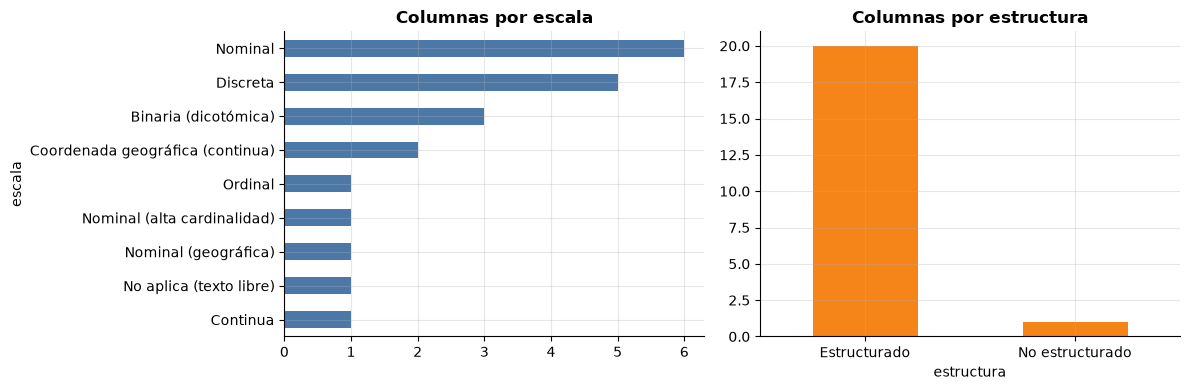

In [27]:
if df_z is not None:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    perfil_z["escala"].str.replace(r" · guardada como texto", "", regex=True).value_counts().sort_values().plot.barh(
        ax=ax[0], color="#4C78A8", title="Columnas por escala")
    perfil_z["estructura"].value_counts().plot.bar(ax=ax[1], color="#F58518", title="Columnas por estructura", rot=0)
    plt.tight_layout(); plt.show()

    ocultas = perfil_z[perfil_z["escala"].str.contains("guardada como texto")]
    if len(ocultas):
        print("⚠️ Columnas numéricas/fecha guardadas como TEXTO (hay que convertirlas antes de analizar):")
        display(ocultas[["columna", "ejemplo", "escala"]])

## 9.3 Una demostración por cada tipo encontrado
El código elige automáticamente la **primera columna** de cada tipo y le aplica el análisis que corresponde.

#### Continua → `Aggregate rating`  _(otras del mismo tipo: 0)_

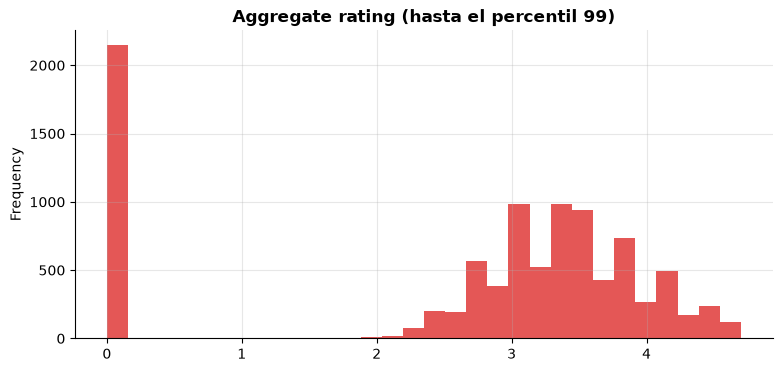

count    9551.00
mean        2.67
std         1.52
min         0.00
25%         2.50
50%         3.20
75%         3.70
max         4.90


#### Discreta → `Restaurant ID`  _(otras del mismo tipo: 4)_

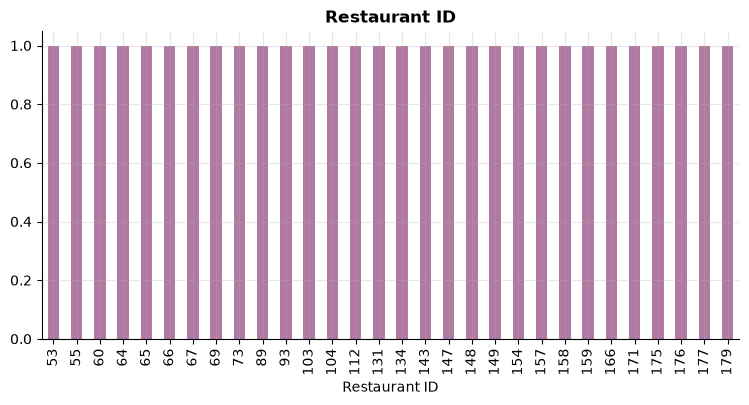

Media: 9051128.35 | Mediana: 6004089.0


#### Nominal → `Restaurant Name`  _(otras del mismo tipo: 7)_

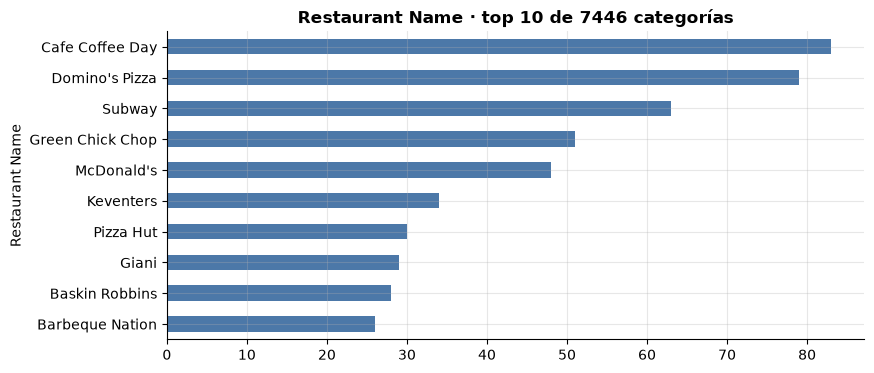

Moda: Cafe Coffee Day


#### Ordinal → `Rating text`  _(otras del mismo tipo: 0)_

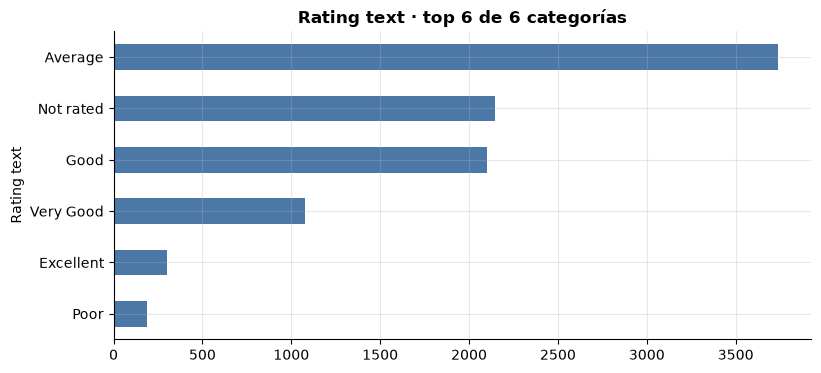

Moda: Average


#### Binaria → `Has Table booking`  _(otras del mismo tipo: 2)_

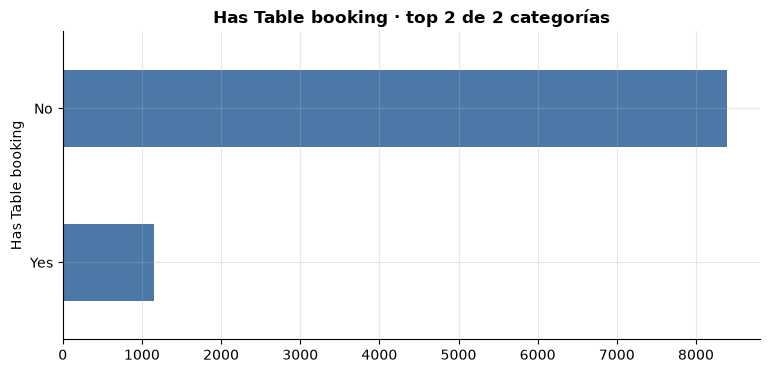

Moda: No

— Fecha / tiempo: este dataset no tiene columnas de este tipo —


#### Texto libre (no estructurado) → `Address`  _(otras del mismo tipo: 0)_

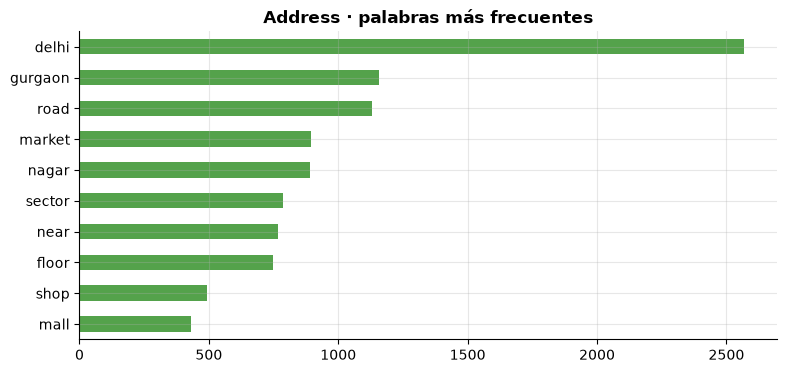

Longitud media: 54 caracteres

— JSON / anidado (semiestructurado): este dataset no tiene columnas de este tipo —


In [28]:
def numerica(df, c):
    s = df[c]
    return s if pd.api.types.is_numeric_dtype(s) else _a_numero(s)


def demo_automatica(df, perfil):
    demos = [
        ("Continua", lambda p: p["escala"].str.startswith("Continua")),
        ("Discreta", lambda p: p["escala"].str.startswith("Discreta")),
        ("Nominal", lambda p: p["escala"].str.startswith("Nominal")),
        ("Ordinal", lambda p: p["escala"].str.startswith("Ordinal")),
        ("Binaria", lambda p: p["escala"].str.startswith("Binaria")),
        ("Fecha / tiempo", lambda p: p["escala"].str.startswith("Intervalo")),
        ("Texto libre (no estructurado)", lambda p: p["estructura"] == "No estructurado"),
        ("JSON / anidado (semiestructurado)", lambda p: p["estructura"] == "Semiestructurado"),
    ]
    for titulo, filtro in demos:
        m = perfil[filtro(perfil)]
        if m.empty:
            print(f"\n— {titulo}: este dataset no tiene columnas de este tipo —")
            continue
        c = m["columna"].iloc[0]
        display(Markdown(f"#### {titulo} → `{c}`  _(otras del mismo tipo: {len(m) - 1})_"))
        if titulo == "Continua":
            x = numerica(df, c).dropna()
            x[x <= x.quantile(.99)].plot.hist(bins=30, color="#E45756", title=f"{c} (hasta el percentil 99)")
            plt.show(); print(x.describe().round(2).to_string())
        elif titulo == "Discreta":
            x = numerica(df, c).dropna()
            x[x <= x.quantile(.99)].round().value_counts().sort_index().head(30).plot.bar(color="#B279A2", title=c)
            plt.show(); print("Media:", round(x.mean(), 2), "| Mediana:", x.median())
        elif titulo in ("Nominal", "Ordinal", "Binaria"):
            vc = df[c].astype(str).value_counts()
            vc.head(10).sort_values().plot.barh(color="#4C78A8", title=f"{c} · top {min(10, len(vc))} de {len(vc)} categorías")
            plt.show(); print("Moda:", vc.index[0])
        elif titulo == "Fecha / tiempo":
            f = pd.to_datetime(df[c], errors="coerce").dropna()
            print("Rango:", f.min(), "→", f.max())
            f.dt.to_period("M").value_counts().sort_index().plot(title=f"{c} · registros por mes"); plt.show()
        elif titulo.startswith("Texto"):
            t = df[c].dropna().astype(str)
            pal = t.str.lower().str.findall(r"[a-záéíóúñü]{4,}")
            top = Counter(w for l in pal.head(5000) for w in l).most_common(10)
            pd.Series(dict(top)).sort_values().plot.barh(color="#54A24B", title=f"{c} · palabras más frecuentes")
            plt.show(); print("Longitud media:", round(t.str.len().mean()), "caracteres")
        else:
            v = df[c].dropna().astype(str).iloc[0]
            try:
                obj = json.loads(v)
            except Exception:
                obj = ast.literal_eval(v)
            print("Primer valor (recortado):", str(obj)[:300], "...")
            print("Tipo de objeto Python:", type(obj).__name__, "· elementos:", len(obj))


if df_z is not None:
    demo_automatica(df_z, perfil_z)

# 10 · Resumen: ¿cómo clasifico una variable?

```
¿Tiene filas/columnas fijas?
├── No ── ¿Tiene claves y estructura anidada? ── Sí → SEMIESTRUCTURADO (JSON, XML)
│                                              └─ No → NO ESTRUCTURADO (texto, imagen, audio)
└── Sí (ESTRUCTURADO)
    ├── ¿Son categorías?
    │    ├── ¿Solo 2 valores? ............ BINARIA
    │    ├── ¿Tienen orden? .............. ORDINAL
    │    └── Sin orden ................... NOMINAL  (si solo identifica: IDENTIFICADOR)
    └── ¿Son números / fechas / coordenadas?
         ├── ¿Se cuentan (enteros)? ...... DISCRETA
         ├── ¿Se miden (decimales)? ...... CONTINUA
         │      ├── cero arbitrario ...... INTERVALO (°C, fechas)
         │      └── cero real ............ RAZÓN (ingreso, edad)
         ├── ¿Es fecha/hora? ............. TEMPORAL
         └── ¿Es lat/long? ............... GEOESPACIAL
```

### Tabla resumen: el mismo concepto en las dos fuentes

| Tipo | Ejemplo en el Excel | Dónde buscarlo en Zomato (Kaggle) |
|---|---|---|
| Nominal | `ciudad`, `genero` | ubicación, tipo de restaurante, nombre |
| Ordinal | `satisfaccion`, `nivel_educacion` | categorías de calificación (si existen) |
| Binaria | `es_suscriptor` | pedido online / reserva de mesa (sí/no) |
| Discreta | `num_pedidos`, `edad` | votos, número de reseñas |
| Continua | `ingreso_mensual_usd` | costo para dos, calificación |
| Temporal | `ventas_diarias.fecha` | fechas, si las hay |
| Geoespacial | `latitud`, `longitud` | latitud/longitud, si las hay |
| Semiestructurado | `ficha_json` | listas o diccionarios serializados |
| No estructurado | `resenas.texto` | reseñas y comentarios en texto |

> Lo que no exista en el dataset de Zomato lo indica la sección 9.3 con el mensaje *"este dataset no tiene columnas de este tipo"*.

# ✍️ Actividad propuesta

1. En el Excel, **cambia la escala** de `satisfaccion` a números 1–5. ¿Qué cálculos nuevos parecen posibles y cuáles siguen sin tener sentido?
2. Elige 3 columnas de Zomato donde el clasificador haya fallado o dudado y **justifica** el tipo correcto.
3. Convierte una columna "guardada como texto" de Zomato en numérica y grafica su distribución.
4. Aplica `perfil_tabla()` a otra hoja del Excel (por ejemplo `planas`, la tabla del JSON aplanado) y comenta el resultado.
5. Escribe tu propio ejemplo de dato **no estructurado** y propón 3 variables estructuradas que podrías extraer de él.

###  Conclusiones
- El **tipo de dato** determina qué análisis son válidos.
- Un mismo número puede ser de **naturaleza distinta** (ID, ordinal codificado, discreto, continuo).
- Los datos **semi y no estructurados** se analizan convirtiéndolos primero en variables estructuradas.
- Las heurísticas automáticas ayudan, pero **el criterio del analista** es la validación final.